# Data: Acquiring, Cleaning and Reshaping

## *Workshop 2*  [![Open In Colab](https://github.com/oballinger/BASC0005/blob/main/colab-badge.png?raw=1)](https://colab.research.google.com/github/oballinger/BASC0005/blob/main/notebooks/W02.%20Pandas.ipynb)

This week's lecture made three points: **dirty data can do real damage**, there are **three ways to get data** (download, API, scrape), and **data types and data structure** (long vs wide, tidy data) decide what you can do with a dataset. This workshop practises each of them with *pandas*, in the same order.

### Aims

- Diagnose a real, consequential spreadsheet error (Reinhart & Rogoff, 2010)
- Get data three ways: download a CSV, call an API (World Bank), scrape an HTML table
- Inspect `dtypes` and fix the usual problems: numbers stored as text, dates as strings, categories
- Select rows and columns with `.loc[]` and boolean filters
- Reshape panel data between **wide** and **long** with `melt()` and `pivot()`, using Global Fishing Watch data
- Get into the habit of asking "is this result real, or is it an artefact of the data?"

The core path should take about two hours. Sections marked **(Optional)** are extensions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 20)

## 1. Dirty data kills: Reinhart & Rogoff

In 2010 Carmen Reinhart and Kenneth Rogoff published *Growth in a Time of Debt*. Its headline: countries with public debt above 90% of GDP had average real growth of about **−0.1%**. Politicians used it to justify austerity. In 2013 Thomas Herndon, a graduate student, tried to replicate it from the authors' own spreadsheet and got **+2.2%** instead ([Herndon, Ash & Pollin, 2013](https://doi.org/10.1093/cje/bet075)).

Below is the replication dataset: one row per **country-year**, with debt/GDP (%) and real GDP growth (%), for 20 advanced economies from 1946 to 2009.

In [2]:
rr = pd.read_csv("https://storage.googleapis.com/qm2/2627/w02/reinhart_rogoff.csv")
print(rr.shape)
rr.head()

(1175, 4)


,Country,Year,debtgdp,dRGDP
0,Australia,1946,190.42,-3.558
1,Australia,1947,177.32,2.459
2,Australia,1948,148.93,6.438
3,Australia,1949,125.83,6.612
4,Australia,1950,109.81,6.920


Reinhart and Rogoff grouped country-years into four debt "buckets". `pd.cut` does this: it turns a continuous number into an ordered **categorical** variable (we come back to categories in section 3).

In [3]:
buckets = [0, 30, 60, 90, np.inf]
labels = ["0-30%", "30-60%", "60-90%", "90%+"]
rr["debt_bucket"] = pd.cut(rr["debtgdp"], bins=buckets, labels=labels, right=False)

rr["debt_bucket"].value_counts().sort_index()

debt_bucket
0-30%     426
30-60%    439
60-90%    200
90%+      110
Name: count, dtype: int64

### The "published" analysis

Here is an analysis that reproduces the steps behind the 2010 headline figure. Read it carefully and run it.

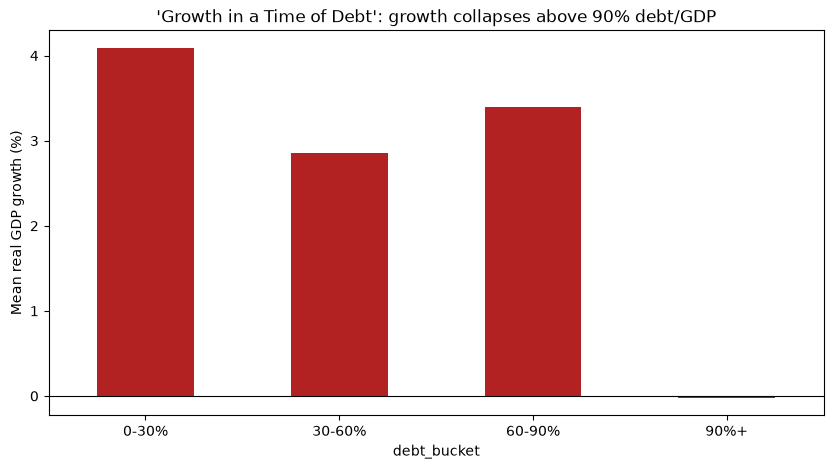

debt_bucket
0-30%     4.09
30-60%    2.85
60-90%    3.40
90%+     -0.02
Name: dRGDP, dtype: float64

In [4]:
countries = sorted(rr["Country"].unique())
sample = rr[rr["Country"].isin(countries[5:])]

early_years = (((sample["Country"] == "New Zealand") & (sample["Year"] < 1950)) |
               ((sample["Country"] == "Australia") & (sample["Year"] < 1951)) |
               ((sample["Country"] == "Canada") & (sample["Year"] < 1951)))
sample = sample[~early_years]

country_means = sample.groupby(["debt_bucket", "Country"], observed=True)["dRGDP"].mean()
published = country_means.groupby("debt_bucket", observed=True).mean()

published.plot(kind="bar", color="firebrick")
plt.axhline(0, color="black", lw=0.8)
plt.ylabel("Mean real GDP growth (%)")
plt.title("'Growth in a Time of Debt': growth collapses above 90% debt/GDP")
plt.xticks(rotation=0)
plt.show()
published.round(2)

Now the simplest possible analysis: take **every** country-year in the data and average growth within each bucket.

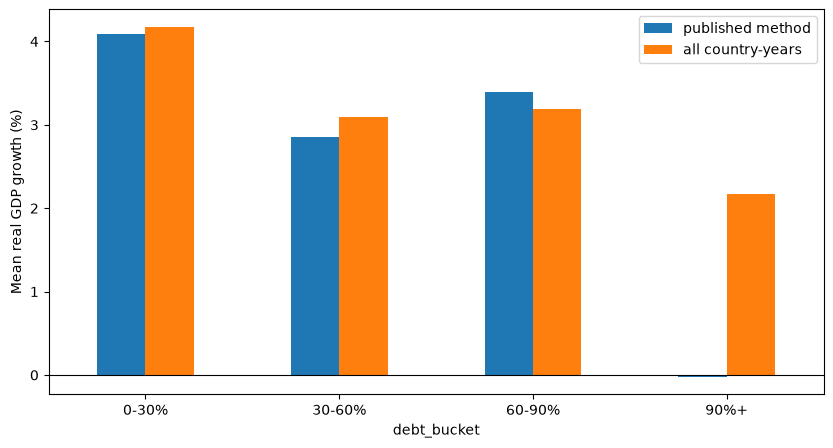

,published method,all country-years
debt_bucket,,
0-30%,4.09,4.17
30-60%,2.85,3.09
60-90%,3.40,3.19
90%+,-0.02,2.17


In [5]:
simple = rr.groupby("debt_bucket", observed=True)["dRGDP"].mean()

compare = pd.DataFrame({"published method": published, "all country-years": simple})
compare.plot(kind="bar")
plt.axhline(0, color="black", lw=0.8)
plt.ylabel("Mean real GDP growth (%)")
plt.xticks(rotation=0)
plt.show()
compare.round(2)

### Exercise: spot the spreadsheet error

The two methods agree for the first three buckets but disagree dramatically above 90%. The "published" cell makes **three** choices that the simple average does not.

1. Identify all three. (Hint: read the published cell line by line. What does `countries[5:]` keep? Which country-years does `early_years` remove? How many country-years does each country contribute to the 90%+ bucket, and how much weight does each country get in the final average?)
2. Undo them **one at a time** and record the 90%+ number after each change. Which choice matters most?
3. Look at the 90%+ bucket country by country (`sample[sample["debt_bucket"] == "90%+"].groupby("Country")["dRGDP"].agg(["mean", "count"])`). One country has a single observation. What does that one year do to an average where every country counts equally?

Only one of the three choices was an accident (the Excel formula did not reach the first five rows). The other two were methodological decisions. Are they defensible?

In [6]:
# your code here

**Interpretation.** Even with the corrected numbers, high-debt country-years grow more slowly (about 2.2% vs 3-4%). Does that mean debt *causes* slow growth? Write two sentences on why the causation could run the other way.

## 2. Data acquisition

The lecture listed three ways to get data from the internet:

| Method | What you get | Example below |
|---|---|---|
| **Download** | a packaged file (CSV, Excel...) | UK incomes by percentile (IFS) |
| **API** | structured data (usually JSON) returned by a server in response to a URL | World Bank GDP |
| **Web scraping** | whatever is displayed on a web page | Netflix Top 10 |

### 2.1 Download: UK incomes by percentile

This file comes from the Institute for Fiscal Studies ([where do you fit in?](https://ifs.org.uk/tools_and_resources/where_do_you_fit_in)), based on the Family Resources Survey 2010-11. Each row is a percentile of the income distribution, and incomes are **equivalised**: adjusted for household size, because a couple needs more than a single person but not twice as much ([equivalisation](https://en.wikipedia.org/wiki/Equivalisation)).

`read_csv` can read straight from a URL, so you do not need to download anything by hand. We use the first column (the percentile) as the index.

In [7]:
income = pd.read_csv("https://s3.eu-west-2.amazonaws.com/qm2/wk2/incomes.csv", index_col=0)
income.head()

,"Net equivalised household income in 2010-11, week","Childless couple, annual income","Couple, two children under 14","Couple, three children under 14",Couple with one child under 14,Couple with two children aged 15 to 18,"Couple, two children under 14 plus dependent adult",Single adult,"Lone parent, one child under 14","Lone parent, two children under 14","Lone parent, two children aged 15-18",ANNOTATIONS,1979 to 1996-97,1996-97 to 2009-10,1996-97 to 2010-11
Percentile Point,,,,,,,,,,,,,,,
1,33.50,"1,746.92","2,445.69","2,795.08","2,096.31","2,899.89","3,022.18","1,170.44","1,519.82","1,869.21","2,323.41",NaN,NaN,NaN,NaN
2,98.60,"5,141.01","7,197.41","8,225.61","6,169.21","8,534.07","8,893.95","3,444.48","4,472.68","5,500.88","6,837.54",NaN,-0.20%,-1.30%,-0.50%
3,128.56,"6,703.11","9,384.36","10,724.98","8,043.74","11,127.17","11,596.39","4,491.09","5,831.71","7,172.33","8,915.14",NaN,0.40%,0.10%,0.10%
4,151.05,"7,875.75","11,026.05","12,601.20","9,450.90","13,073.75","13,625.05","5,276.75","6,851.90","8,427.05","10,474.75",NaN,0.50%,0.80%,0.60%
5,166.32,"8,671.91","12,140.68","13,875.06","10,406.30","14,395.38","15,002.41","5,810.18","7,544.57","9,278.95","11,533.65",NaN,0.70%,1.00%,0.90%


The last row is the top percentile, "the 1%":

In [8]:
income.tail()

,"Net equivalised household income in 2010-11, week","Childless couple, annual income","Couple, two children under 14","Couple, three children under 14",Couple with one child under 14,Couple with two children aged 15 to 18,"Couple, two children under 14 plus dependent adult",Single adult,"Lone parent, one child under 14","Lone parent, two children under 14","Lone parent, two children aged 15-18",ANNOTATIONS,1979 to 1996-97,1996-97 to 2009-10,1996-97 to 2010-11
Percentile Point,,,,,,,,,,,,,,,
95,1075.73,"56,088.56","78,523.99","89,741.70","67,306.27","93,107.01","97,033.21","37,579.34","48,797.05","60,014.76","74,597.79",NaN,2.90%,2.00%,1.30%
96,1174.48,"61,237.18","85,732.05","97,979.49","73,484.61","101,653.72","105,940.32","41,028.91","53,276.35","65,523.78","81,445.45",NaN,3.00%,2.00%,1.40%
97,1302.74,"67,925.07","95,095.10","108,680.12","81,510.09","112,755.62","117,510.37","45,509.80","59,094.81","72,679.83","90,340.35",NaN,3.20%,2.20%,1.60%
98,1523.31,"79,425.23","111,195.32","127,080.36","95,310.27","131,845.88","137,405.64","53,214.90","69,099.95","84,984.99","105,635.55",NaN,3.20%,2.70%,1.70%
99,2090.35,"108,990.74","152,587.04","174,385.19","130,788.89","180,924.64","188,553.99","73,023.80","94,821.95","116,620.10","144,957.69",NaN,NaN,NaN,NaN


#### Selecting rows, columns and cells

- a **row** by its index label: `income.loc[90]`
- a range of rows: `income.loc[90:95]` (with `.loc`, the end point is *included*)
- a **column** by name: `income["Single adult"]`
- a single **cell**: `income.loc[90, "Single adult"]`

`.iloc[]` does the same by *position* (0, 1, 2, ...) rather than by label.

In [9]:
weekly = "Net equivalised household income in 2010-11, week"
income.loc[90:95, weekly]

Percentile Point
90     845.54
91     876.63
92     911.29
93     957.14
94    1016.37
95    1075.73
Name: Net equivalised household income in 2010-11, week, dtype: float64

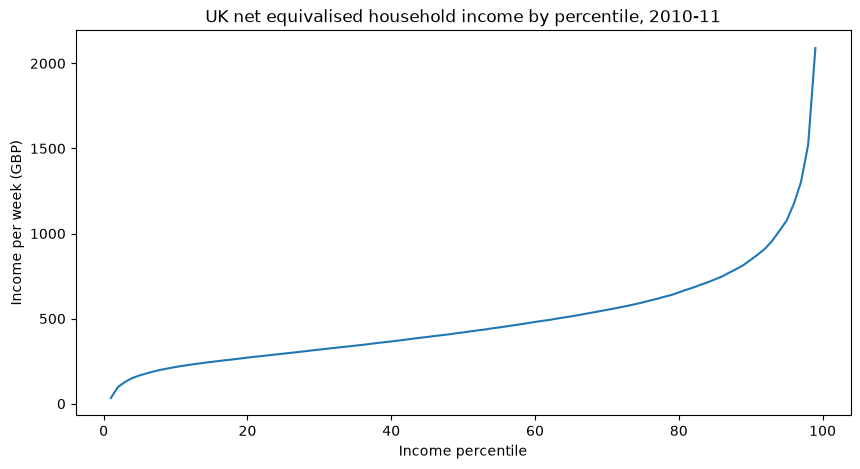

In [10]:
income[weekly].plot()
plt.title("UK net equivalised household income by percentile, 2010-11")
plt.xlabel("Income percentile")
plt.ylabel("Income per week (GBP)")
plt.show()

Linear through the middle, then a steep rise at the top.

### Exercise: mean vs median

Add horizontal lines (`plt.axhline`) for the **mean** and the **median** of the weekly income column to the plot above. Which is higher, and why? What does the median mean in this context?

(Careful: the mean of 99 percentile points is not the mean household income. Why not?)

In [11]:
# your code here

### 2.2 API: the World Bank

An API is a URL that returns data instead of a web page. As in the lecture's Google Maps example, the URL has a **base** and some **parameters**. The World Bank's API needs no key:

`https://api.worldbank.org/v2/country/AGO;BRA;COL/indicator/NY.GDP.MKTP.CD?format=json&date=2000:2024&per_page=1000`

- `country/AGO;BRA;COL`: Angola, Brazil, Colombia (ISO3 codes, separated by `;`)
- `indicator/NY.GDP.MKTP.CD`: GDP in current US$ (search for indicator codes at [data.worldbank.org](https://data.worldbank.org))
- `format=json`, `date=2000:2024`, `per_page=1000`: return JSON, for these years, all on one page

Paste the URL into your browser to see the raw response first. `requests` lets us pass the parameters as a dictionary:

In [12]:
url = "https://api.worldbank.org/v2/country/AGO;BRA;COL/indicator/NY.GDP.MKTP.CD"
params = {"format": "json", "date": "2000:2024", "per_page": 1000}

response = requests.get(url, params=params, timeout=30)
print(response.status_code)   # 200 = OK
meta, records = response.json()
meta

200


{'page': 1,
 'pages': 1,
 'per_page': 1000,
 'total': 75,
 'sourceid': '2',
 'lastupdated': '2026-07-13'}

The response is **JSON**: a list containing a metadata dictionary and a list of records. Each record is a dictionary, and some values are dictionaries themselves (**nested**):

In [13]:
records[0]

{'indicator': {'id': 'NY.GDP.MKTP.CD', 'value': 'GDP (current US$)'},
 'country': {'id': 'AO', 'value': 'Angola'},
 'countryiso3code': 'AGO',
 'date': '2024',
 'value': 103080538044.058,
 'unit': '',
 'obs_status': '',
 'decimal': 0}

`pd.json_normalize` flattens nested JSON into a table: `country: {"value": "Angola"}` becomes a column called `country.value`.

In [14]:
gdp = pd.json_normalize(records)
gdp = gdp[["country.value", "countryiso3code", "date", "value"]]
gdp.columns = ["country", "iso3", "year", "gdp_usd"]
gdp.head()

,country,iso3,year,gdp_usd
0,Angola,AGO,2024,1.030805e+11
1,Angola,AGO,2023,1.060423e+11
2,Angola,AGO,2022,1.282340e+11
3,Angola,AGO,2021,7.828392e+10
4,Angola,AGO,2020,5.851203e+10


Before plotting, **check the dtypes**. Is `year` a number?

In [15]:
gdp.dtypes

country        str
iso3           str
year           str
gdp_usd    float64
dtype: object

`year` is stored as text (`object` in pandas 2, `str` in pandas 3), because JSON sent it as `"2024"` in quotes. Text sorts alphabetically and cannot go on a numeric axis, so convert it:

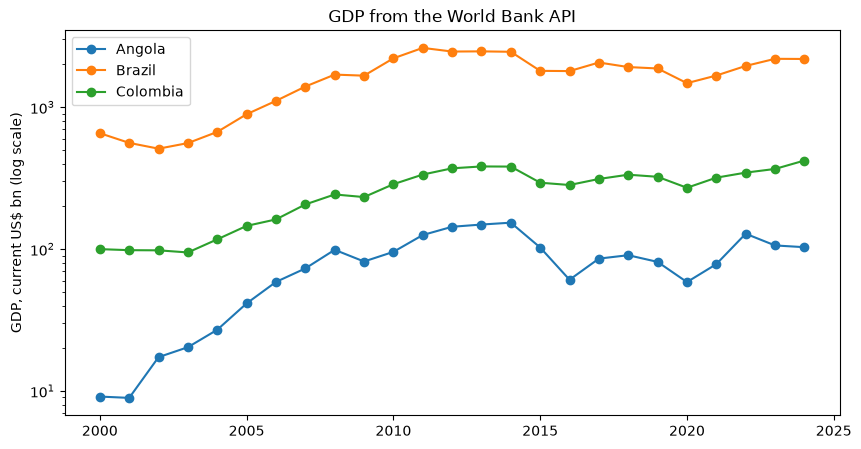

In [16]:
gdp["year"] = gdp["year"].astype(int)
gdp["gdp_bn"] = gdp["gdp_usd"] / 1e9

for country, group in gdp.groupby("country"):
    group = group.sort_values("year")
    plt.plot(group["year"], group["gdp_bn"], marker="o", label=country)
plt.yscale("log")
plt.ylabel("GDP, current US$ bn (log scale)")
plt.legend()
plt.title("GDP from the World Bank API")
plt.show()

### Exercise: another indicator

Use the same pattern to get a different indicator for the same three countries, for example total fisheries production in metric tons (`ER.FSH.PROD.MT`) or population (`SP.POP.TOTL`). Plot it. Do any years come back as `NaN` (missing)? Why might that be?

In [17]:
# your code here

**Interpretation.** The lecture slide (made a few years ago) gave Angola's 2019 GDP as **69.3** US$ bn. What does the API say now?

In [18]:
gdp[gdp["year"].between(2019, 2021)].pivot(index="country", columns="year", values="gdp_bn").round(1)

year,2019,2020,2021
country,,,
Angola,81.2,58.5,78.3
Brazil,1873.3,1476.1,1670.6
Colombia,323.0,270.3,318.5


Same source, same country, same year, different number. Official statistics are **revised** as better information arrives, so a number is only meaningful alongside the date you downloaded it (its *vintage*). This is one reason to fetch data with code: you can re-run the script and see exactly what changed.

### 2.3 Web scraping: the Netflix Top 10

When there is no download or API, you can take data from the page itself. For HTML tables, `pd.read_html` does it in one line and returns a **list** of every table on the page. (The page changes every week, so your output will differ from the one saved here.)

In [19]:
tables = pd.read_html("https://top10.netflix.com/")
print(len(tables), "table(s) found")
top10 = tables[0]
top10

1 table(s) found


,Ranking,Unnamed: 1,Views,Runtime,Hours Viewed
0,01Why Did I Get Married Again?,2,9700000,1:51,17900000
1,02The Whisper Man,4,6200000,1:54,11800000
2,03Riot,1,5200000,1:27,7500000
3,04The Seemingly Perfect Family,1,4600000,1:27,6700000
4,05Best of the Best,1,4300000,1:52,8000000
5,06The Ministry of Ungentlemanly Warfare,1,3400000,2:00,6800000
6,07Puss in Boots: The Last Wish,7,2900000,1:42,5000000
7,08KPop Demon Hunters,65,2500000,1:40,4200000
8,09A Minecraft Movie,1,2500000,1:41,4200000
9,10Shrek,19,2200000,1:30,3300000


This is typical scraped data: it *looks* right on screen but is messy underneath.
- The rank and the title have been squashed into one column (`"01Why Did I..."`).
- One column has no name (`Unnamed: 1`; on the website it is the number of weeks in the Top 10).
- `Runtime` is text like `"1:51"`, not a duration.

Check with `.dtypes`, then fix it:

In [20]:
top10.dtypes

Ranking           str
Unnamed: 1      int64
Views           int64
Runtime           str
Hours Viewed    int64
dtype: object

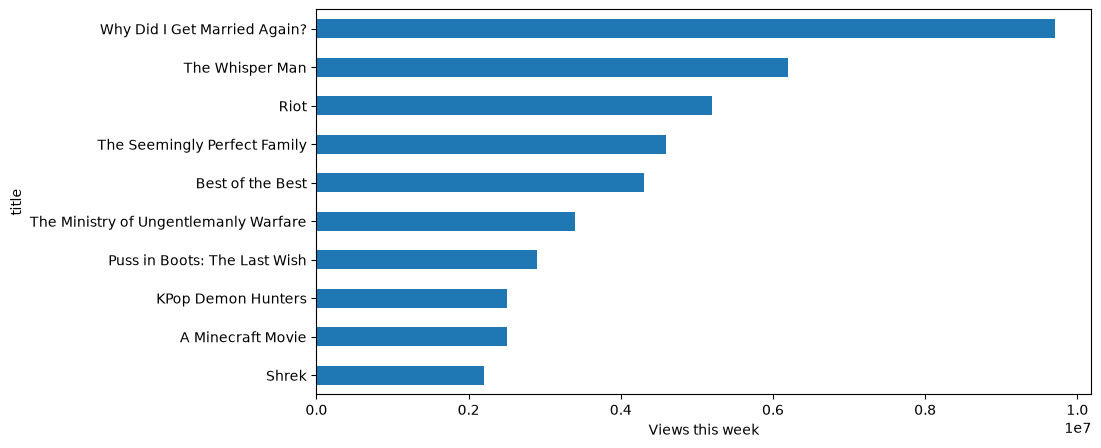

,rank,title,weeks_in_top10,Views,runtime_min,Hours Viewed
0,1,Why Did I Get Married Again?,2,9700000,111.0,17900000
1,2,The Whisper Man,4,6200000,114.0,11800000
2,3,Riot,1,5200000,87.0,7500000
3,4,The Seemingly Perfect Family,1,4600000,87.0,6700000
4,5,Best of the Best,1,4300000,112.0,8000000
5,6,The Ministry of Ungentlemanly Warfare,1,3400000,120.0,6800000
6,7,Puss in Boots: The Last Wish,7,2900000,102.0,5000000
7,8,KPop Demon Hunters,65,2500000,100.0,4200000
8,9,A Minecraft Movie,1,2500000,101.0,4200000
9,10,Shrek,19,2200000,90.0,3300000


In [21]:
top10 = top10.rename(columns={top10.columns[1]: "weeks_in_top10"})
top10["rank"] = top10["Ranking"].str[:2].astype(int)     # first two characters
top10["title"] = top10["Ranking"].str[2:]                 # everything after them
top10["runtime"] = pd.to_timedelta(top10["Runtime"] + ":00")   # "1:51" -> 1 h 51 min
top10["runtime_min"] = top10["runtime"].dt.total_seconds() / 60

top10 = top10[["rank", "title", "weeks_in_top10", "Views", "runtime_min", "Hours Viewed"]]
top10.plot.barh(x="title", y="Views", legend=False)
plt.gca().invert_yaxis()
plt.xlabel("Views this week")
plt.show()
top10

**Interpretation.** Netflix defines "Views" as hours viewed divided by runtime. Check this with the columns you have. Which kind of title does this definition favour, long or short ones?

> **Scraping etiquette.** Scraping can break a site's terms of service; check them, and never hammer a site with requests. Some sites (Wikipedia included) refuse requests that do not identify themselves. If `read_html(url)` gives `HTTP Error 403: Forbidden`, fetch the page with `requests.get(url, headers={"User-Agent": "BASC0005 student project"})` and pass `io.StringIO(response.text)` to `read_html`.

### (Optional) Exercise: scrape a Wikipedia table

Scrape the ranking of countries by exclusive economic zone (EEZ) area from `https://en.wikipedia.org/wiki/Exclusive_economic_zone` (the table with columns `Rank`, `Country`, `EEZ (km2)`, `Shelf (km2)`). The page has about 20 tables: use `read_html(..., match="Shelf")` to select the right one, then tidy the column names (remove footnote markers like `[103]`) and check the dtypes. Make a bar chart of the 15 largest EEZs. Which country comes first, and why is that surprising? (Hint: what counts as one country's EEZ here?)

In [22]:
import io
# your code here

## 3. Data types

The lecture's pandas dtypes:

| pandas dtype | Python type | Used for |
|---|---|---|
| `int64` | `int` | whole numbers |
| `float64` | `float` | decimals, and any numeric column containing `NaN` |
| `bool` | `bool` | True/False |
| `object` / `str` | `str` | text (and anything pandas could not parse) |
| `datetime64` | `datetime` | dates and times |
| `category` | (none) | a fixed set of labels |

The most common data problem is a column of numbers that pandas has read as **text**. Everything looks fine until you try to calculate with it.

### 3.1 Numbers stored as text

Try to plot two household types from the income data:

In [23]:
try:
    income[["Single adult", "Childless couple, annual income"]].plot()
except TypeError as err:
    print("TypeError:", err)

TypeError: no numeric data to plot


"No numeric data to plot", although we can see the numbers. `.dtypes` tells us why:

In [24]:
income.dtypes

Net equivalised household income in 2010-11, week     float64
Childless couple, annual income                           str
Couple, two children under 14                             str
Couple, three children under 14                           str
Couple with one child under 14                            str
Couple with two children aged 15 to 18                    str
Couple, two children under 14 plus dependent adult        str
Single adult                                              str
Lone parent, one child under 14                           str
Lone parent, two children under 14                        str
Lone parent, two children aged 15-18                      str
ANNOTATIONS                                               str
1979 to 1996-97                                           str
1996-97 to 2009-10                                        str
1996-97 to 2010-11                                        str
dtype: object

Only the weekly column is numeric. Look at a raw value:

In [25]:
income.loc[50, "Single adult"]

'14,627.95'

`'14,627.95'`: the comma makes the value readable for humans and unreadable as a number. The fix: remove the commas, then convert with `pd.to_numeric`. With `errors="coerce"`, anything that still cannot be parsed becomes `NaN` instead of raising an error. **Always count the NaNs afterwards**: coercion is silent, and it can quietly turn real values into missing ones.

Single adult                       float64
Childless couple, annual income    float64
dtype: object
NaNs created: 0


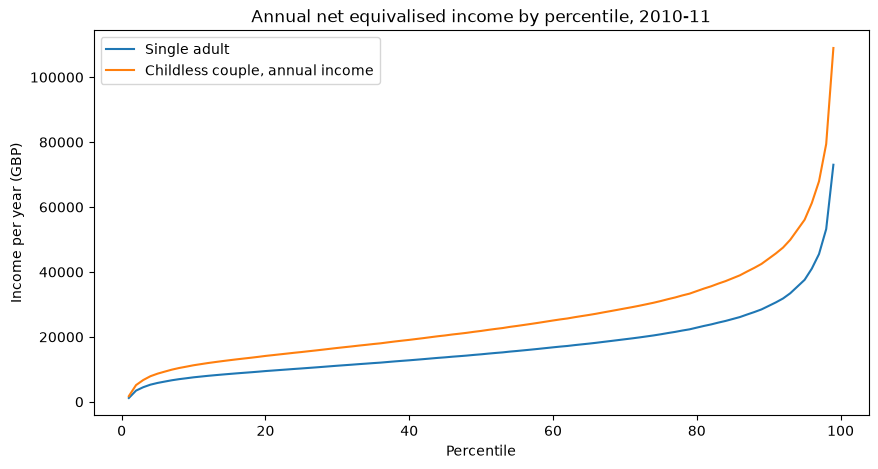

In [26]:
cols = ["Single adult", "Childless couple, annual income"]
clean = income[cols].apply(lambda col: pd.to_numeric(col.str.replace(",", ""), errors="coerce"))

print(clean.dtypes)
print("NaNs created:", clean.isna().sum().sum())
clean.plot()
plt.title("Annual net equivalised income by percentile, 2010-11")
plt.xlabel("Percentile")
plt.ylabel("Income per year (GBP)")
plt.show()

It is usually better to fix types **when reading the file**. `read_csv` has arguments for exactly this:

In [27]:
income2 = pd.read_csv("https://s3.eu-west-2.amazonaws.com/qm2/wk2/incomes.csv", index_col=0,
                      thousands=",")
income2.dtypes

Net equivalised household income in 2010-11, week     float64
Childless couple, annual income                       float64
Couple, two children under 14                         float64
Couple, three children under 14                       float64
Couple with one child under 14                        float64
Couple with two children aged 15 to 18                float64
Couple, two children under 14 plus dependent adult    float64
Single adult                                          float64
Lone parent, one child under 14                       float64
Lone parent, two children under 14                    float64
Lone parent, two children aged 15-18                  float64
ANNOTATIONS                                               str
1979 to 1996-97                                           str
1996-97 to 2009-10                                        str
1996-97 to 2010-11                                        str
dtype: object

### Exercise: what is still wrong?

`thousands=","` fixed most columns, but not all of them.

1. Which columns are still text, and why? Look at their values.
2. Convert the three growth-rate columns (`"1979 to 1996-97"` etc.) to numbers. (Hint: `.str.rstrip("%")`, and remember to divide by 100 if you want proportions.)
3. The `ANNOTATIONS` column has one non-missing value. What is it, and why does it break the rule "one column = one variable"?

In [28]:
# your code here

### 3.2 Filtering by value

A boolean condition gives a column of True/False values, one per row. Put it inside `[ ]` to keep only the rows where it is True:

In [29]:
clean["Childless couple, annual income"] > 50000

Percentile Point
1     False
2     False
3     False
4     False
5     False
      ...  
95     True
96     True
97     True
98     True
99     True
Name: Childless couple, annual income, Length: 99, dtype: bool

In [30]:
clean[clean["Childless couple, annual income"] > 50000]

,Single adult,"Childless couple, annual income"
Percentile Point,,
94,35505.56,52993.38
95,37579.34,56088.56
96,41028.91,61237.18
97,45509.80,67925.07
98,53214.90,79425.23
99,73023.80,108990.74


Comparison operators: `==` (equal; a single `=` means assignment), `!=`, `<`, `<=`, `>`, `>=`. Combine conditions with `&` (and) and `|` (or), with each condition in brackets.

### Exercise: single adults

On a properly labelled graph, plot the incomes of single adults whose net equivalised income is at most £10,000 a year. What proportion of the population is this? Then compare single adults with childless couples at the 1st, 50th and 99th percentiles: what does it tell you about the equivalisation scale?

In [31]:
# your code here

### 3.3 Categories and dates

Two more dtypes you will meet constantly:

- **category**: a variable that takes a small, fixed set of values (flag state, gear type, region). Storing it as `category` uses less memory, and an **ordered** category (like the debt buckets from section 1) sorts in its logical order, not alphabetically.
- **datetime**: text like `"2023-07"` means nothing to pandas until you convert it with `pd.to_datetime`. After conversion you can extract years and months, sort in time order and resample.

In [32]:
print(rr["debt_bucket"].dtype)
print(rr["debt_bucket"].cat.categories.tolist())

rr["Country"] = rr["Country"].astype("category")
rr.dtypes

category
['0-30%', '30-60%', '60-90%', '90%+']


Country        category
Year              int64
debtgdp         float64
dRGDP           float64
debt_bucket    category
dtype: object

In [33]:
months = pd.Series(["Nov 2023", "Feb 2023", "Jan 2024"])
print(months.sort_values().tolist())        # sorted as text: alphabetical, not chronological

dates = pd.to_datetime(months, format="%b %Y")
print(dates.sort_values().dt.strftime("%b %Y").tolist())
print(dates.dt.year.tolist(), dates.dt.month_name().tolist())

try:
    pd.to_datetime(pd.Series(["03/04/2024", "13/04/2024"]), format="%m/%d/%Y")
except ValueError as err:
    print("ValueError:", str(err)[:80])

['Feb 2023', 'Jan 2024', 'Nov 2023']
['Feb 2023', 'Nov 2023', 'Jan 2024']
[2023, 2023, 2024] ['November', 'February', 'January']
ValueError: time data "13/04/2024" doesn't match format "%m/%d/%Y". You might want to try:
 


The last line is the classic date trap: `03/04/2024` is 3 April in the UK and March 4 in the US. Always pass an explicit `format=`, so that pandas fails loudly rather than silently guessing.

## 4. Panel data: wide vs long

**Panel data** records the same units (countries, vessels, firms) repeatedly over time. The lecture showed World Bank GDP in two layouts:

- **wide**: one row per country, one column per year. Compact, and how most published tables look.
- **long**: one row per country × year. More repetition, but adding a variable means adding one column, and it is what `groupby`, plotting and regression expect.

Our API result is already long. `pivot` makes it wide, which reproduces the lecture's table:

In [34]:
gdp_wide = gdp.pivot(index="country", columns="year", values="gdp_bn")
gdp_wide[[2019, 2020, 2021]].round(1)

year,2019,2020,2021
country,,,
Angola,81.2,58.5,78.3
Brazil,1873.3,1476.1,1670.6
Colombia,323.0,270.3,318.5


`melt` goes the other way, from wide to long. `id_vars` stays fixed, and all the other columns are "melted" into two: one holding the old column names (`var_name`) and one holding the values (`value_name`).

In [35]:
gdp_long = gdp_wide.reset_index().melt(id_vars="country", var_name="year", value_name="gdp_bn")
print(gdp_wide.shape, "->", gdp_long.shape)
gdp_long.head()

(3, 25) -> (75, 3)


,country,year,gdp_bn
0,Angola,2000,9.129595
1,Brazil,2000,655.448232
2,Colombia,2000,99.875075
3,Angola,2001,8.936079
4,Brazil,2001,559.983635


### 4.1 Global Fishing Watch: fishing effort by flag state

[Global Fishing Watch](https://globalfishingwatch.org) uses the AIS signals that ships broadcast to estimate where and when vessels are fishing. The file below gives **apparent fishing hours** per month for the ten flag states with the most fishing effort, 2017-2024. Like many published datasets it comes in **wide** format: one row per flag and one column per month.

*Data: Global Fishing Watch, [fishing effort v3](https://globalfishingwatch.org/dataset-and-code-fishing-effort/), licensed CC BY-NC 4.0.*

In [36]:
fish_wide = pd.read_csv("https://storage.googleapis.com/qm2/2627/w02/fishing_hours_by_flag_wide.csv",
                        index_col="flag")
print(fish_wide.shape)
fish_wide.iloc[:, :6]

(10, 96)


,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06
flag,,,,,,
CHN,516065.0,491399.0,931656.0,1374245,262149,305613
TWN,181201.0,157107.0,164549.0,231917,227847,210907
KOR,90687.0,86070.0,104216.0,117044,162617,178586
ESP,152648.0,137025.0,177311.0,168193,219950,230783
ITA,135206.0,170771.0,205276.0,174239,273744,287198
RUS,135968.0,145381.0,174577.0,153922,150192,153760
USA,105330.0,119962.0,121349.0,123421,129441,149916
JPN,125162.0,104445.0,103993.0,105902,129725,130546
FRA,129467.0,118467.0,145698.0,136067,139850,141090


Ten rows and 96 columns. (Why are the first few columns shown as decimals and the rest as whole numbers? Look for `NaN`.) The column names are **values** (months), not variable names: that is the lecture's first cause of messiness. To plot a time series or compute annual totals, we want long format with one row per flag × month:

In [37]:
fish = fish_wide.reset_index().melt(id_vars="flag", var_name="month", value_name="fishing_hours")
fish["month"] = pd.to_datetime(fish["month"], format="%Y-%m")
fish["flag"] = fish["flag"].astype("category")
print(fish.dtypes)
fish.head()

flag                   category
month            datetime64[us]
fishing_hours           float64
dtype: object


,flag,month,fishing_hours
0,CHN,2017-01-01,516065.0
1,TWN,2017-01-01,181201.0
2,KOR,2017-01-01,90687.0
3,ESP,2017-01-01,152648.0
4,ITA,2017-01-01,135206.0


To plot, pivot back so that time is the index and each flag is a column (one line per column). A common workflow is **long for analysis, wide for plotting**:

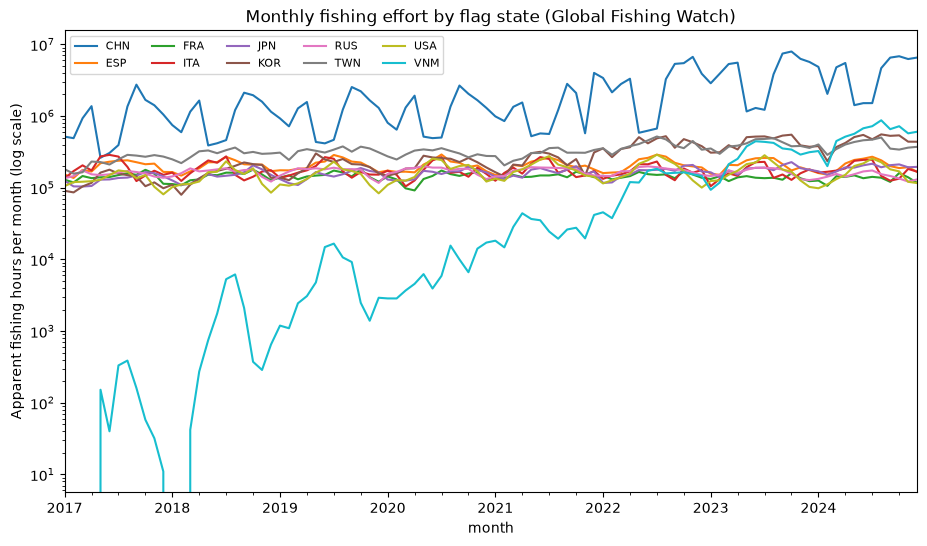

In [38]:
fish.pivot(index="month", columns="flag", values="fishing_hours").plot(logy=True, figsize=(11, 6))
plt.ylabel("Apparent fishing hours per month (log scale)")
plt.title("Monthly fishing effort by flag state (Global Fishing Watch)")
plt.legend(ncol=5, fontsize=8)
plt.show()

Now that the data is long and `month` is a real datetime, questions become one-liners. Seasonality in China's fleet:

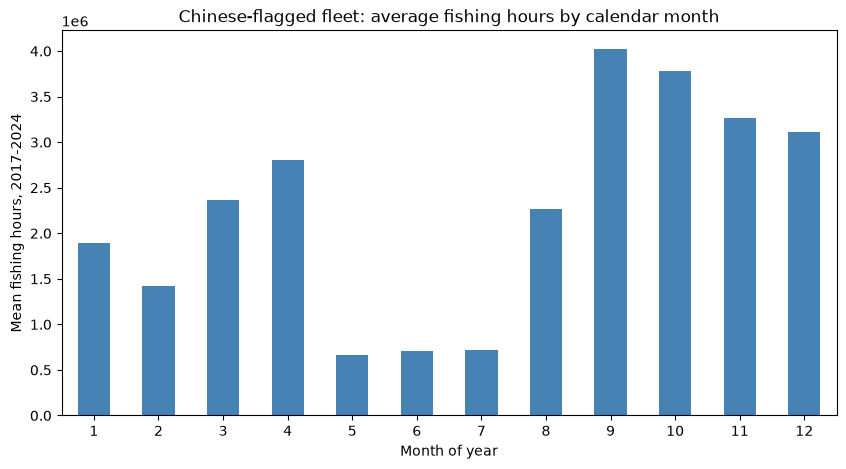

In [39]:
chn = fish[fish["flag"] == "CHN"]
chn.groupby(chn["month"].dt.month)["fishing_hours"].mean().plot(kind="bar", color="steelblue")
plt.xlabel("Month of year")
plt.ylabel("Mean fishing hours, 2017-2024")
plt.title("Chinese-flagged fleet: average fishing hours by calendar month")
plt.xticks(rotation=0)
plt.show()

### Exercise: seasonality

Is the dip in the middle of the year a data problem or something real? (Hint: search for *China summer fishing moratorium*.) Make the same plot for a European flag (for example `ESP` or `FRA`). Is there a similar pattern?

In [40]:
# your code here

### Exercise: spot the problem

A blog post writes:

> *"Fishing by the world's top ten fleets nearly **tripled** between 2017 and 2024. Vietnam's fishing effort grew more than a thousand-fold. The oceans are being emptied faster than ever."*

1. Reproduce the numbers: compute annual totals per flag (`fish["month"].dt.year` and `groupby`), then a bar chart of the ten-flag total by year.
2. Which flags drive the jump, and in which years? Does the jump look like a gradual trend or a step change?
3. These are hours *detected through AIS*. List at least two reasons why detected fishing could rise without any real change in fishing (think about which vessels carry AIS transponders, and about the satellites that receive their signals).
4. `fish_wide` has some missing values. Which flag and months? What does `.sum()` do with `NaN`, and how could that inflate a growth rate?
5. The ten flags were chosen *because* they have the most fishing hours over 2017-2024. How does that selection affect the conclusion?

In [41]:
# your code here

### Tidy data: recap

The lecture's rules, which you have now applied to real data:

1. Each **column** is one variable (not a value like `2019-03`, and not a mix like `"01Why Did I..."`).
2. Each **row** is one observation (one country-year, one flag-month).
3. Values are **numeric** where possible, with the right dtype (no `"14,627.95"`, no `"1:51"`).
4. Metadata (footnotes, annotations like "Poverty line") does not belong inside a data column.

**Next:** the reading-week notebook (*Merging and Joining*) shows how to combine two tidy tables that share a key, for example World Bank indicators and GFW effort by country. Week 3 extends this to joining on *location*.